In [1]:
from google.colab import files
updated = files.upload()

import zipfile
import io


for fn in updated.keys():
  if fn.endswith('.zip'):
    zip_ref = zipfile.ZipFile(io.BytesIO(updated[fn]), 'r')
    zip_ref.extractall('/') # Extract to the root directory for easy access
    zip_ref.close()

import pandas as pd
# Now, read the extracted CSV file
df = pd.read_csv('/mtsamples.csv')
df

Saving mtsamples.csv.zip to mtsamples.csv.zip


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."
...,...,...,...,...,...,...
4994,4994,Patient having severe sinusitis about two to ...,Allergy / Immunology,Chronic Sinusitis,"HISTORY:, I had the pleasure of meeting and e...",NaN
4995,4995,This is a 14-month-old baby boy Caucasian who...,Allergy / Immunology,Kawasaki Disease - Discharge Summary,"ADMITTING DIAGNOSIS: , Kawasaki disease.,DISCH...","allergy / immunology, mucous membranes, conjun..."
4996,4996,A female for a complete physical and follow u...,Allergy / Immunology,Followup on Asthma,"SUBJECTIVE: , This is a 42-year-old white fema...",NaN
4997,4997,Mother states he has been wheezing and coughing.,Allergy / Immunology,Asthma in a 5-year-old,"CHIEF COMPLAINT: , This 5-year-old male presen...",NaN


In [2]:
# Load and explore the data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Load data
df = pd.read_csv('/mtsamples.csv', index_col=0)
print(df.shape)
print(df.head())
print(df.columns.tolist())
print(df.dtypes)

(4999, 5)
                                         description  \
0   A 23-year-old white female presents with comp...   
1           Consult for laparoscopic gastric bypass.   
2           Consult for laparoscopic gastric bypass.   
3                             2-D M-Mode. Doppler.     
4                                 2-D Echocardiogram   

             medical_specialty                                sample_name  \
0         Allergy / Immunology                         Allergic Rhinitis    
1                   Bariatrics   Laparoscopic Gastric Bypass Consult - 2    
2                   Bariatrics   Laparoscopic Gastric Bypass Consult - 1    
3   Cardiovascular / Pulmonary                    2-D Echocardiogram - 1    
4   Cardiovascular / Pulmonary                    2-D Echocardiogram - 2    

                                       transcription  \
0  SUBJECTIVE:,  This 23-year-old white female pr...   
1  PAST MEDICAL HISTORY:, He has difficulty climb...   
2  HISTORY OF PRESENT 

In [3]:
# Understand the key columns

# The columns you care about most:
# 'medical_specialty' — the label you're predicting
# 'transcription' — the clinical note text (your input)
# 'description' — brief summary of the note

print(df['medical_specialty'].value_counts())
print(f"\nNumber of specialties: {df['medical_specialty'].nunique()}")
print(f"\nMissing values:\n{df.isnull().sum()}")

medical_specialty
Surgery                          1103
Consult - History and Phy.        516
Cardiovascular / Pulmonary        372
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  230
Neurology                         223
SOAP / Chart / Progress Notes     166
Obstetrics / Gynecology           160
Urology                           158
Discharge Summary                 108
ENT - Otolaryngology               98
Neurosurgery                       94
Hematology - Oncology              90
Ophthalmology                      83
Nephrology                         81
Emergency Room Reports             75
Pediatrics - Neonatal              70
Pain Management                    62
Psychiatry / Psychology            53
Office Notes                       51
Podiatry                           47
Dermatology                        29
Dentistry                          27
Cosmetic / Plastic Surgery      

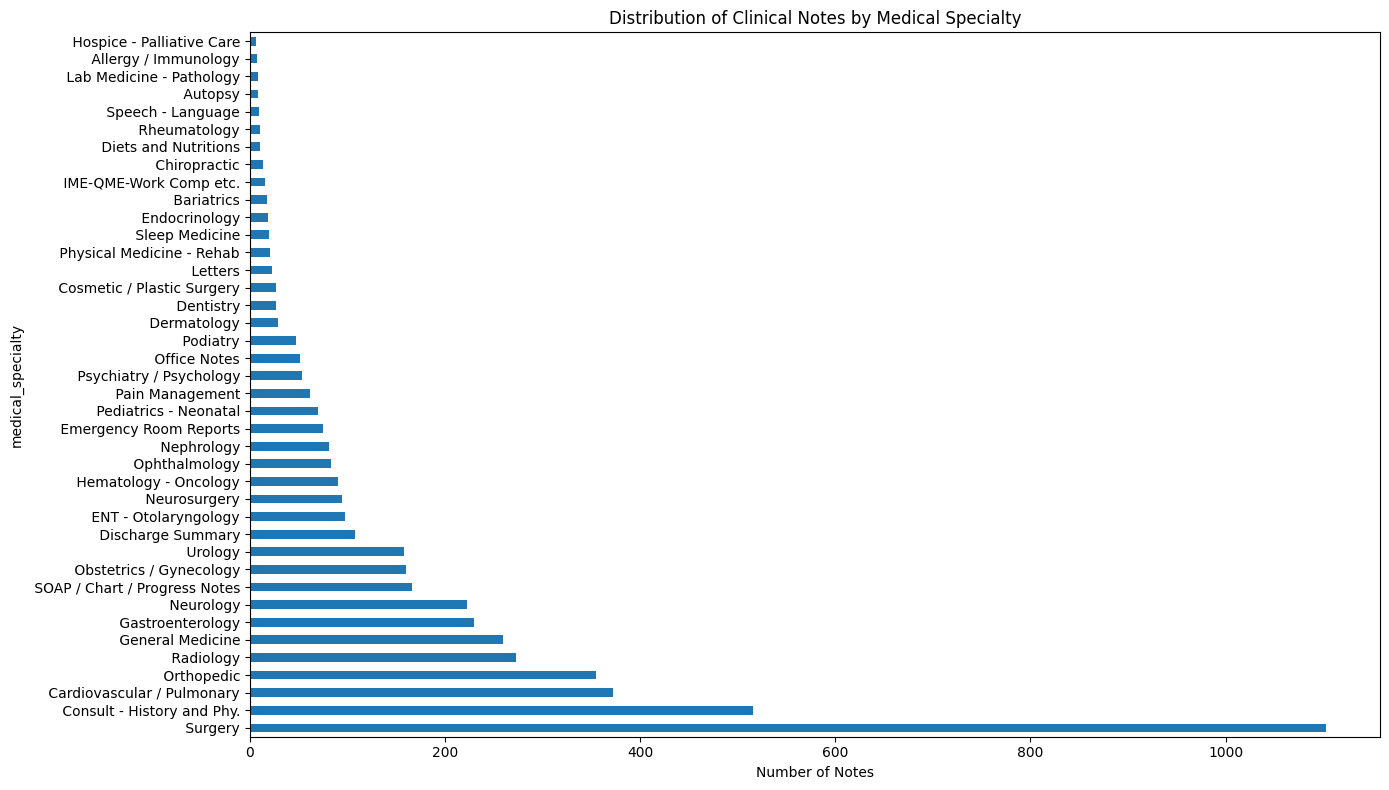


Top 5 specialties:
medical_specialty
Surgery                       1103
Consult - History and Phy.     516
Cardiovascular / Pulmonary     372
Orthopedic                     355
Radiology                      273
Name: count, dtype: int64

Bottom 5 specialties:
medical_specialty
Speech - Language            9
Autopsy                      8
Lab Medicine - Pathology     8
Allergy / Immunology         7
Hospice - Palliative Care    6
Name: count, dtype: int64


In [4]:
# Visualise the specialty distribution

import os

# Count notes per specialty
specialty_counts = df['medical_specialty'].value_counts()

plt.figure(figsize=(14, 8))
specialty_counts.plot(kind='barh')
plt.xlabel('Number of Notes')
plt.title('Distribution of Clinical Notes by Medical Specialty')
plt.tight_layout()

# Create the 'images' directory if it doesn't exist
output_dir = 'images'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, 'specialty_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTop 5 specialties:\n{specialty_counts.head()}")
print(f"\nBottom 5 specialties:\n{specialty_counts.tail()}")

In [5]:
# Handle the class imbalance problem

# Keep only top 10 specialties
top_10 = specialty_counts.head(10).index.tolist()
df_filtered = df[df['medical_specialty'].isin(top_10)].copy()

print(f"Original dataset: {len(df)} notes")
print(f"Filtered dataset: {len(df_filtered)} notes")
print(f"\nSpecialties kept:\n{df_filtered['medical_specialty'].value_counts()}")

# Drop rows with missing transcription text
df_filtered = df_filtered.dropna(subset=['transcription'])
print(f"\nAfter dropping missing transcriptions: {len(df_filtered)} notes")

Original dataset: 4999 notes
Filtered dataset: 3657 notes

Specialties kept:
medical_specialty
Surgery                          1103
Consult - History and Phy.        516
Cardiovascular / Pulmonary        372
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  230
Neurology                         223
SOAP / Chart / Progress Notes     166
Obstetrics / Gynecology           160
Name: count, dtype: int64

After dropping missing transcriptions: 3630 notes


## Text Preprocessing

In [6]:
# Install NLP libraries

!pip install nltk scikit-learn wordcloud
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [7]:
# Write a text cleaning function

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Add medical stopwords that appear everywhere and add no signal
medical_stopwords = {'patient', 'procedure', 'history', 'diagnosis',
                     'noted', 'placed', 'used', 'performed', 'right',
                     'left', 'including', 'mg', 'also', 'well'}
stop_words.update(medical_stopwords)

def clean_text(text):
    """Clean and preprocess clinical note text"""
    if pd.isna(text):
        return ""

    # Lowercase
    text = text.lower()

    # Remove numbers and special characters
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)

    # Tokenise (split into words)
    tokens = text.split()

    # Remove stopwords and lemmatise (reduce words to root form)
    # e.g. "bleeding", "bled", "bleeds" → "bleed"
    tokens = [lemmatizer.lemmatize(word) for word in tokens
              if word not in stop_words and len(word) > 2]

    return ' '.join(tokens)

# Apply to dataset
df_filtered['cleaned_text'] = df_filtered['transcription'].apply(clean_text)
print(df_filtered['cleaned_text'].head(3))

3    mmode atrial enlargement atrial diameter norma...
4    ventricular cavity size wall thickness appear ...
7    echocardiogrammultiple view heart great vessel...
Name: cleaned_text, dtype: object


Generating word cloud for specialty:  Cardiovascular / Pulmonary


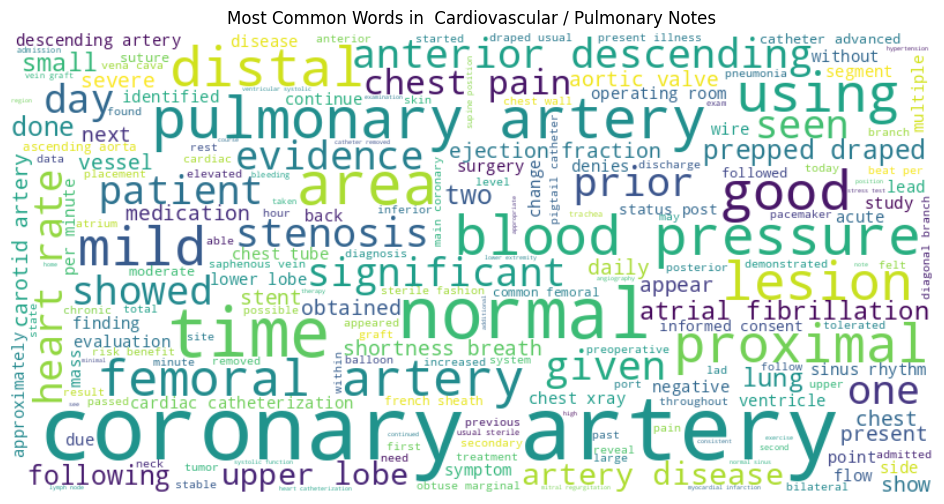

In [8]:
# Visualise most common words per specialty (Word Cloud)

from wordcloud import WordCloud

# Find a specialty with non-empty cleaned text to generate a word cloud
specialty_to_visualize = None
for s in df_filtered['medical_specialty'].unique():
    temp_text = ' '.join(df_filtered[
        df_filtered['medical_specialty'] == s]['cleaned_text'])
    if temp_text: # If temp_text is not empty, we found a suitable specialty
        specialty_to_visualize = s
        break

if specialty_to_visualize:
    print(f"Generating word cloud for specialty: {specialty_to_visualize}")
    specialty_text = ' '.join(df_filtered[
        df_filtered['medical_specialty'] == specialty_to_visualize]['cleaned_text'])

    wordcloud = WordCloud(width=800, height=400,
                          background_color='white').generate(specialty_text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Most Common Words in {specialty_to_visualize} Notes')
    plt.savefig('images/wordcloud.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Could not find any specialty with non-empty cleaned text to generate a word cloud.")
    print("Consider reviewing the 'clean_text' function, the stopwords, or the filtered dataset.")

In [9]:
# Baseline Model

# encode labels and split data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode specialty labels as numbers
le = LabelEncoder()
df_filtered['label'] = le.fit_transform(df_filtered['medical_specialty'])

print("Label mapping:")
for i, specialty in enumerate(le.classes_):
    print(f"  {i}: {specialty}")

X = df_filtered['cleaned_text']
y = df_filtered['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain: {len(X_train)}, Test: {len(X_test)}")

Label mapping:
  0:  Cardiovascular / Pulmonary
  1:  Consult - History and Phy.
  2:  Gastroenterology
  3:  General Medicine
  4:  Neurology
  5:  Obstetrics / Gynecology
  6:  Orthopedic
  7:  Radiology
  8:  SOAP / Chart / Progress Notes
  9:  Surgery

Train: 2904, Test: 726


In [10]:
#  Build TF-IDF + Logistic Regression pipeline

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# A Pipeline chains steps together — first vectorise, then classify
tfidf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
    ('clf', LogisticRegression(max_iter=1000, random_state=42,
                                class_weight='balanced'))
])

tfidf_pipeline.fit(X_train, y_train)
y_pred_tfidf = tfidf_pipeline.predict(X_test)

print(f"TF-IDF + Logistic Regression Accuracy: "
      f"{accuracy_score(y_test, y_pred_tfidf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tfidf,
                            target_names=le.classes_))

TF-IDF + Logistic Regression Accuracy: 0.3912

Classification Report:
                                precision    recall  f1-score   support

    Cardiovascular / Pulmonary       0.33      0.47      0.39        74
    Consult - History and Phy.       0.28      0.20      0.24       103
              Gastroenterology       0.36      0.44      0.40        45
              General Medicine       0.23      0.37      0.28        52
                     Neurology       0.29      0.36      0.32        45
       Obstetrics / Gynecology       0.46      0.74      0.57        31
                    Orthopedic       0.42      0.69      0.52        71
                     Radiology       0.24      0.20      0.22        54
 SOAP / Chart / Progress Notes       0.31      0.33      0.32        33
                       Surgery       0.75      0.36      0.49       218

                      accuracy                           0.39       726
                     macro avg       0.37      0.42      0.38   

In [11]:
# Also try Naive Bayes and SVM

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

models = {
    'Logistic Regression': tfidf_pipeline,
    'Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000)),
        ('clf', MultinomialNB())
    ]),
    'Linear SVM': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000)),
        ('clf', LinearSVC(random_state=42, class_weight='balanced'))
    ])
}

results = {}
for name, model in models.items():
    if name != 'Logistic Regression':  # Already trained above
        model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = {'model': model, 'predictions': preds, 'accuracy': acc}
    print(f"{name}: {acc:.4f}")

Logistic Regression: 0.3912
Naive Bayes: 0.4697
Linear SVM: 0.2810


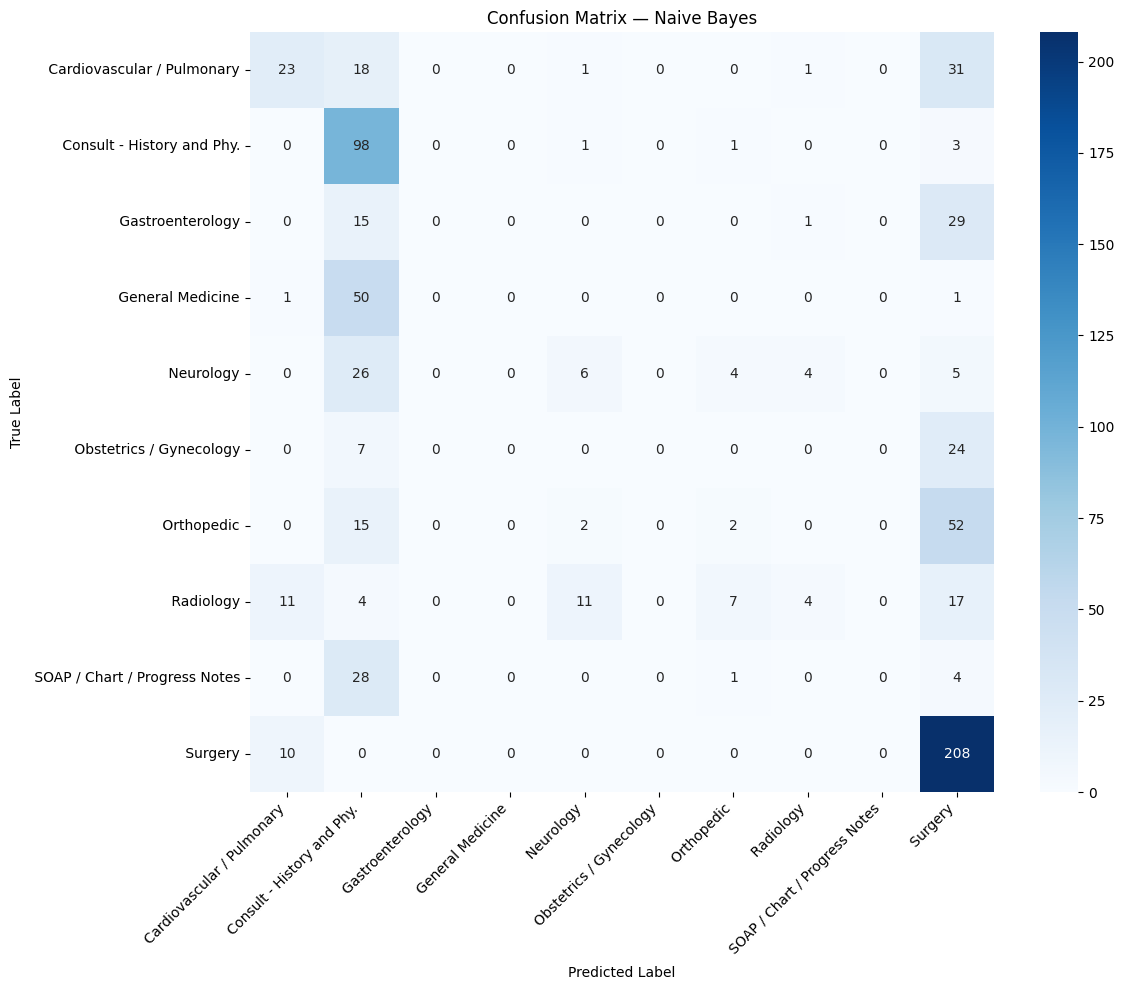

In [12]:
# C0nfusion matrix for best model
best_name = max(results, key=lambda k: results[k]['accuracy'])
best_preds = results[best_name]['predictions']

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix — {best_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('images/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Install HuggingFace Transformers
!pip install transformers torch datasets

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
import torch
from torch.utils.data import Dataset

In [14]:
# Load BioBERT tokeniser
# BioBERT is pre-trained specifically on biomedical text
model_name = "dmis-lab/biobert-base-cased-v1.2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Test the tokeniser
sample = df_filtered['cleaned_text'].iloc[0]
tokens = tokenizer(sample, truncation=True, max_length=512)
print(f"Sample text: {sample[:100]}...")
print(f"Number of tokens: {len(tokens['input_ids'])}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.11k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

Sample text: mmode atrial enlargement atrial diameter normal size ventricle normal systolic function ventricular ...
Number of tokens: 88


In [15]:
# Create a PyTorch Dataset
class ClinicalNotesDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Create datasets
train_dataset = ClinicalNotesDataset(X_train.reset_index(drop=True),
                                      y_train.reset_index(drop=True),
                                      tokenizer)
test_dataset = ClinicalNotesDataset(X_test.reset_index(drop=True),
                                     y_test.reset_index(drop=True),
                                     tokenizer)

In [20]:
# Load and fine-tune BioBERT

from sklearn.metrics import accuracy_score as sk_accuracy
import numpy as np

num_labels = len(le.classes_)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=num_labels)

# Training configuration
training_args = TrainingArguments(
    output_dir='./biobert_results',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs',
    eval_strategy="epoch", # Corrected from evaluation_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {'accuracy': sk_accuracy(labels, predictions)}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

# Train — this will take 15–30 minutes on Colab GPU
# Make sure to enable GPU: Runtime → Change runtime type → T4 GPU
trainer.train()

[transformers] You passed `num_labels=10` which is incompatible to the `id2label` map of length `2`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.226922,0.477961
2,1.440143,1.163921,0.464187
3,0.981953,1.143029,0.429752


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1089, training_loss=1.180792592226419, metrics={'train_runtime': 512.5018, 'train_samples_per_second': 16.999, 'train_steps_per_second': 2.125, 'total_flos': 1146194080948224.0, 'train_loss': 1.180792592226419, 'epoch': 3.0})

In [21]:
# Evaluate BioBERT

# Get predictions
predictions = trainer.predict(test_dataset)
y_pred_biobert = np.argmax(predictions.predictions, axis=-1)

biobert_acc = sk_accuracy(y_test, y_pred_biobert)
print(f"BioBERT Accuracy: {biobert_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_biobert,
                            target_names=le.classes_))

BioBERT Accuracy: 0.4298

Classification Report:
                                precision    recall  f1-score   support

    Cardiovascular / Pulmonary       0.35      0.45      0.40        74
    Consult - History and Phy.       0.40      0.61      0.48       103
              Gastroenterology       0.38      0.40      0.39        45
              General Medicine       0.45      0.10      0.16        52
                     Neurology       0.36      0.36      0.36        45
       Obstetrics / Gynecology       0.40      0.55      0.47        31
                    Orthopedic       0.30      0.32      0.31        71
                     Radiology       0.30      0.26      0.28        54
 SOAP / Chart / Progress Notes       0.41      0.21      0.28        33
                       Surgery       0.61      0.53      0.57       218

                      accuracy                           0.43       726
                     macro avg       0.40      0.38      0.37       726
             

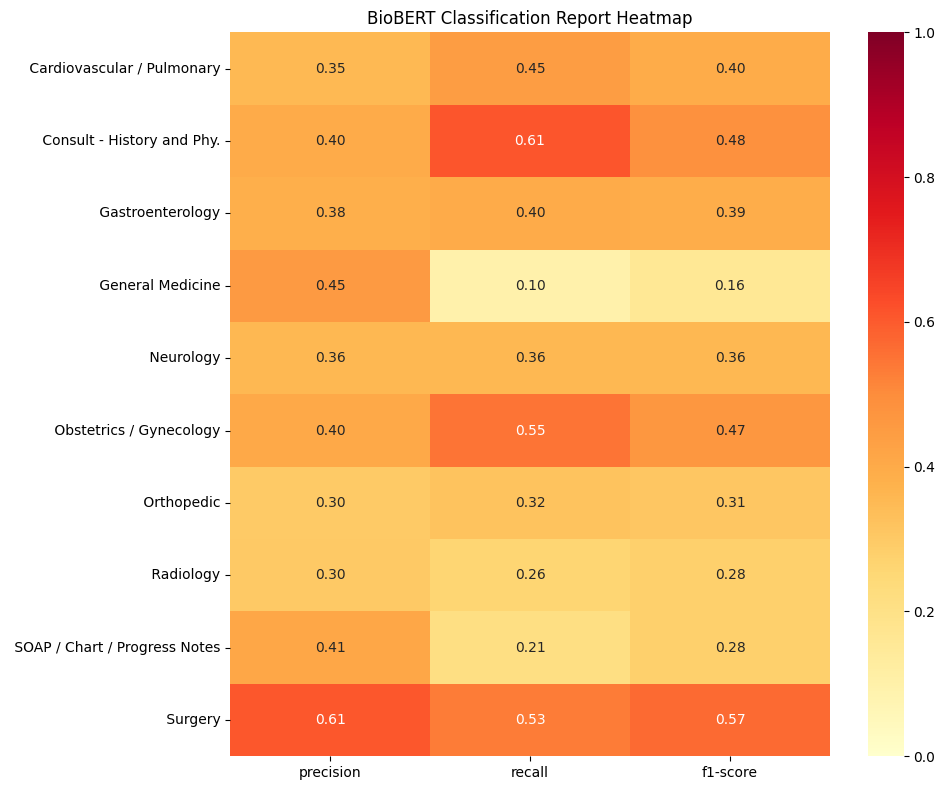

In [22]:
# Classification report Heatmap
from sklearn.metrics import classification_report
import pandas as pd

# Build a heatmap from the classification report
report = classification_report(y_test, y_pred_biobert,
                                target_names=le.classes_,
                                output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df = report_df.iloc[:-3, :-1]  # Remove summary rows

plt.figure(figsize=(10, 8))
sns.heatmap(report_df.astype(float), annot=True, fmt='.2f',
            cmap='YlOrRd', vmin=0, vmax=1)
plt.title('BioBERT Classification Report Heatmap')
plt.tight_layout()
plt.savefig('images/classification_report_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Final model comparison summary

print("=" * 50)
print("FINAL MODEL COMPARISON")
print("=" * 50)
for name, res in results.items():
    print(f"{name}: {res['accuracy']:.4f}")
print(f"BioBERT: {biobert_acc:.4f}")
print("=" * 50)
print(f"Best model: BioBERT")
print(f"Improvement over baseline: "
      f"{(biobert_acc - max(r['accuracy'] for r in results.values())):.4f}")

FINAL MODEL COMPARISON
Logistic Regression: 0.3912
Naive Bayes: 0.4697
Linear SVM: 0.2810
BioBERT: 0.4298
Best model: BioBERT
Improvement over baseline: -0.0399
